# Transient Chaos Tests

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation

In [9]:
sim = FastSitnikovSimulation(e=0.5)

rng = np.random.default_rng(42)

def find_transient_orbits(
    sim,
    *,
    n_candidates=5,
    min_crossings=50,
    max_crossings=100,
    max_attempts=30000,
    t_bounds=(np.pi / 2, 3 * np.pi / 2),
    v_bounds=(1.0, 1.7),
    crossing_limit=150,
):
    candidates = []
    attempts = 0

    while len(candidates) < n_candidates and attempts < max_attempts:
        attempts += 1
        t0 = rng.uniform(*t_bounds)
        v0 = rng.uniform(*v_bounds)
        crossings = sim.crossings_fast(v=v0, t=t0, max_crossings=crossing_limit)

        if min_crossings <= crossings <= max_crossings:
            candidates.append(
                {
                    "idx": len(candidates) + 1,
                    "attempt": attempts,
                    "t": t0,
                    "v": v0,
                    "crossings": crossings,
                }
            )

        if attempts % 1000 == 0:
            print(f"Tried {attempts} samples so far. Found {len(candidates)}/{n_candidates}.")

    if len(candidates) < n_candidates:
        raise RuntimeError(
            f"Found only {len(candidates)} candidates after {max_attempts} attempts. "
            f"Try increasing max_attempts or widening search ranges.",
        )

    return candidates

candidates = find_transient_orbits(sim, n_candidates=5)
candidates

[{'idx': 1,
  'attempt': 64,
  't': 2.6070858881637977,
  'v': 1.1011669322062327,
  'crossings': 97},
 {'idx': 2,
  'attempt': 71,
  't': 3.099678563764332,
  'v': 1.3434948960481647,
  'crossings': 53},
 {'idx': 3,
  'attempt': 125,
  't': 2.746330168653426,
  'v': 1.298117460461457,
  'crossings': 67},
 {'idx': 4,
  'attempt': 134,
  't': 2.465270845797236,
  'v': 1.107529376634441,
  'crossings': 64},
 {'idx': 5,
  'attempt': 268,
  't': 1.6044982174408005,
  'v': 1.146340361021569,
  'crossings': 68}]

The cell below stores an example of a chaotic trajectory

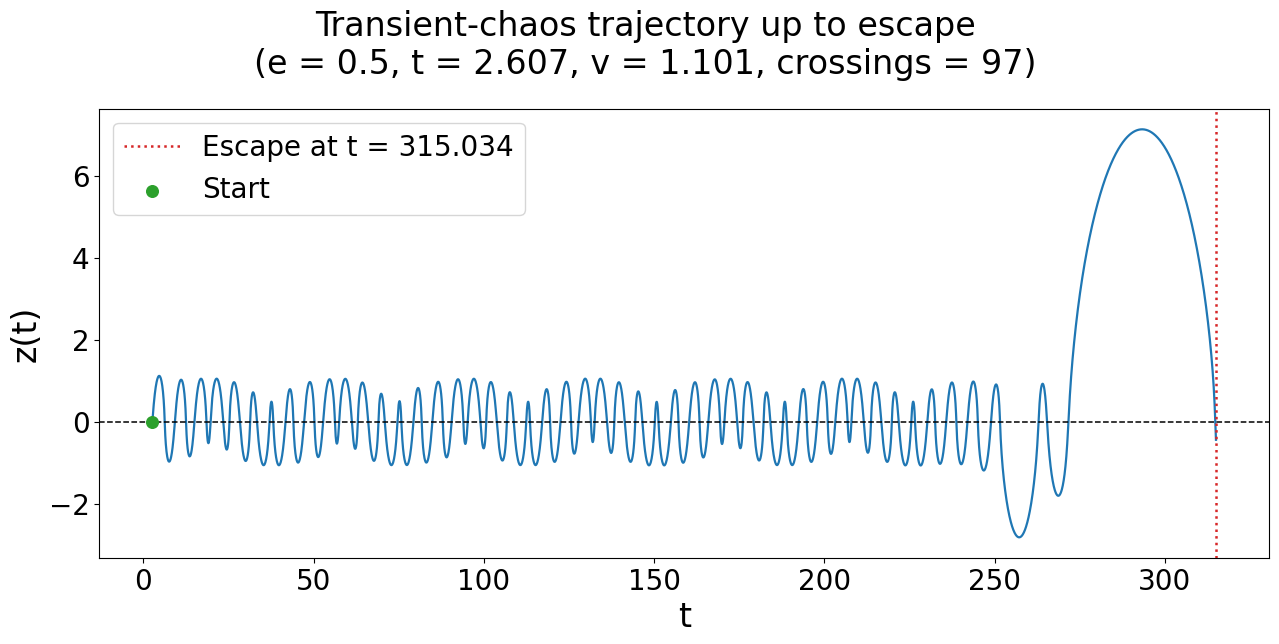

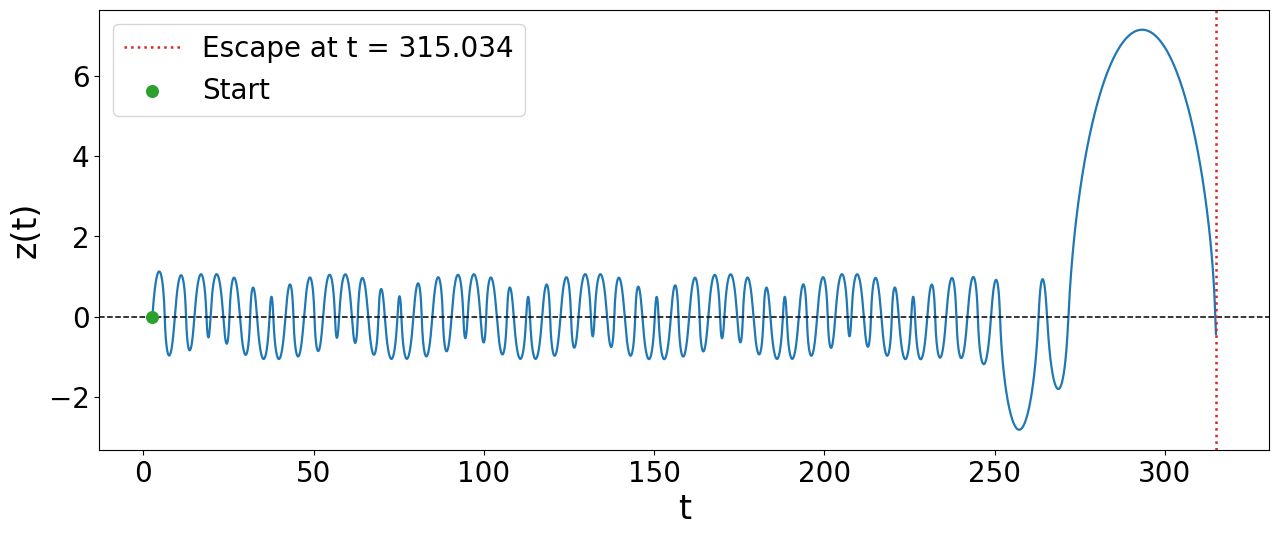

WindowsPath('plots/transient_chaos_trajectory_no_title.pdf')

In [ ]:
# from pathlib import Path
# from scipy.integrate import solve_ivp

# t0 = float(candidate["t"])
# v0 = float(candidate["v"])

# sol = solve_ivp(
#     sim._rhs,
#     (t0, t0 + 200.0 * sim.period),
#     (0.0, v0),
#     method=sim.solver_method,
#     events=(sim._escape_event,),
#     dense_output=True,
#     rtol=sim.rtol,
#     atol=sim.atol,
#     max_step=sim.max_step,
# )

# if len(sol.t_events[0]) == 0:
#     raise RuntimeError("Escape event was not detected within the integration window.")

# t_escape = float(sol.t_events[0][0])
# t_plot = np.linspace(t0, t_escape, 6000)
# z_plot = sol.sol(t_plot)[0]

# plt.rcParams.update({
#     "font.size": 20,
#     "axes.titlesize": 26,
#     "axes.labelsize": 24,
#     "xtick.labelsize": 20,
#     "ytick.labelsize": 20,
#     "legend.fontsize": 20,
# })

# def plot_trajectory(include_title):
#     figsize = (13, 6.6) if include_title else (13, 5.5)
#     fig, ax = plt.subplots(figsize=figsize)
#     if include_title:
#         fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.82)
#     else:
#         fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.94)

#     ax.plot(t_plot, z_plot, lw=1.6, color="tab:blue")
#     ax.axhline(0.0, color="black", ls="--", lw=1.1)
#     ax.axvline(t_escape, color="tab:red", ls=":", lw=1.8, label=f"Escape at t = {t_escape:.3f}")
#     ax.scatter([t0], [0.0], color="tab:green", s=70, zorder=3, label="Start")
#     ax.set_xlabel("t")
#     ax.set_ylabel("z(t)")
#     if include_title:
#         fig.suptitle(
#             "Transient-chaos trajectory up to escape\n"
#             f"(e = 0.5, t = {t0:.3f}, v = {v0:.3f}, crossings = {candidate['crossings']})",
#             y=0.97,
#         )
#     ax.legend(loc="best")
#     return fig

# title_fig = plot_trajectory(include_title=True)
# title_path = Path("plots") / "transient_chaos_trajectory_with_title.pdf"
# title_path.parent.mkdir(parents=True, exist_ok=True)
# title_fig.savefig(title_path)
# plt.show()

# untitled_fig = plot_trajectory(include_title=False)
# untitled_path = Path("plots") / "transient_chaos_trajectory_no_title.pdf"
# untitled_path.parent.mkdir(parents=True, exist_ok=True)
# untitled_fig.savefig(untitled_path)
# plt.show()

# title_path
# untitled_path

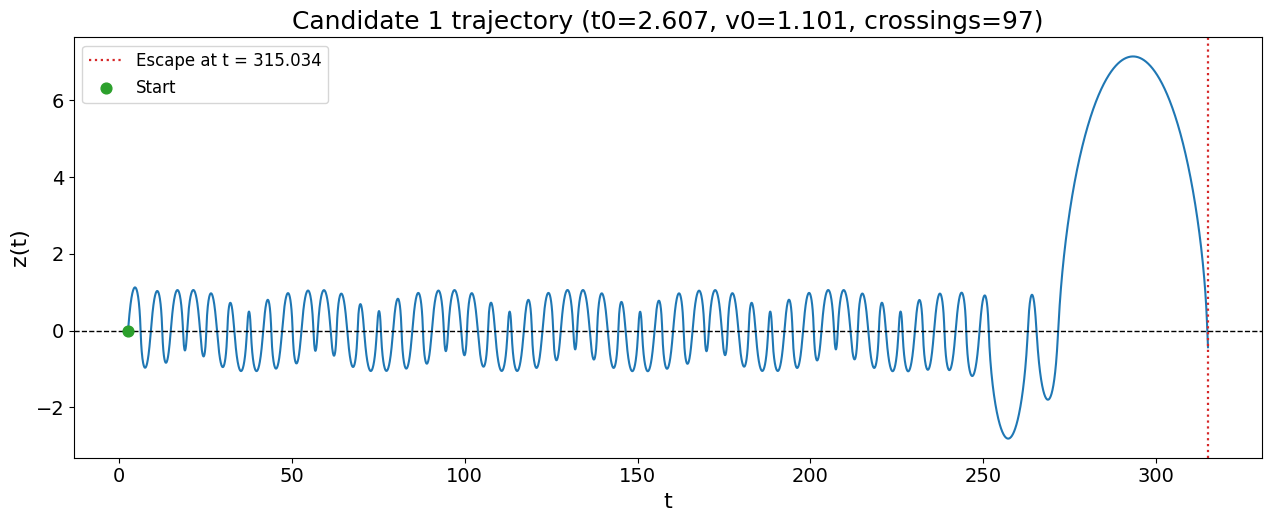

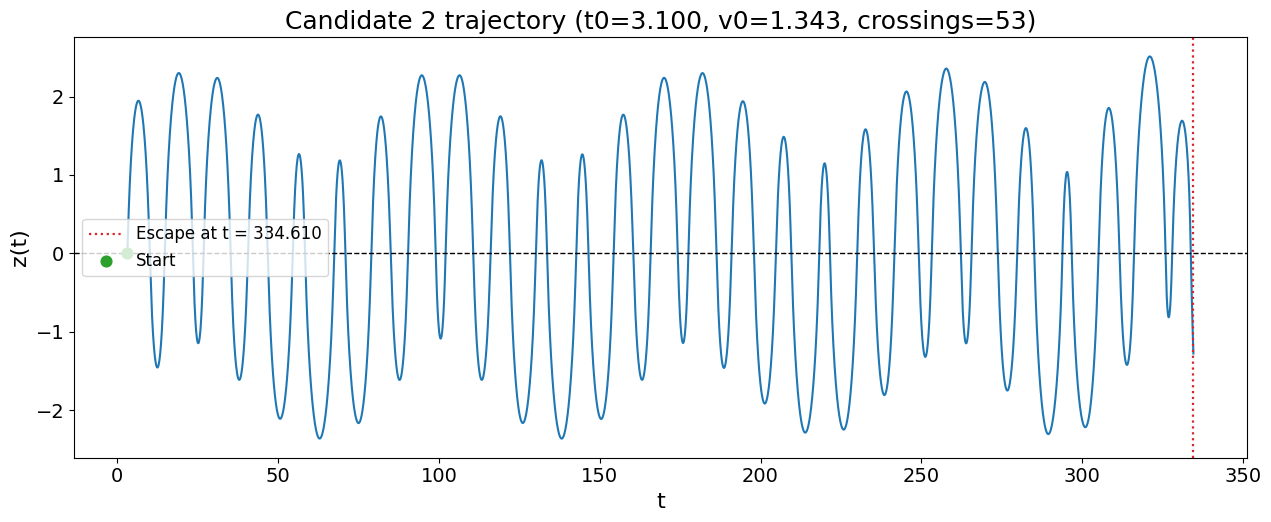

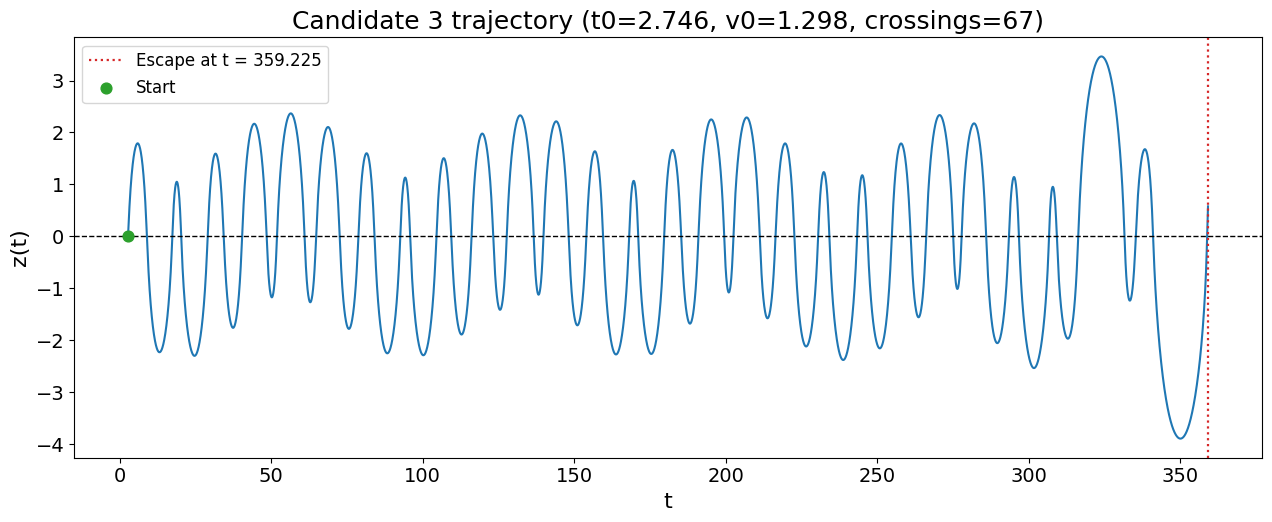

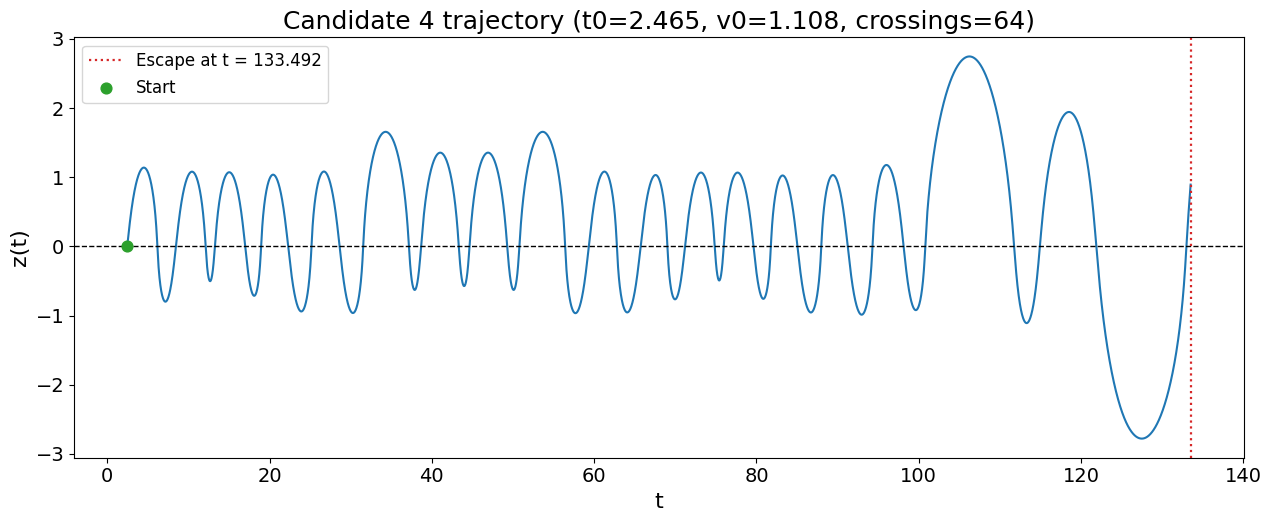

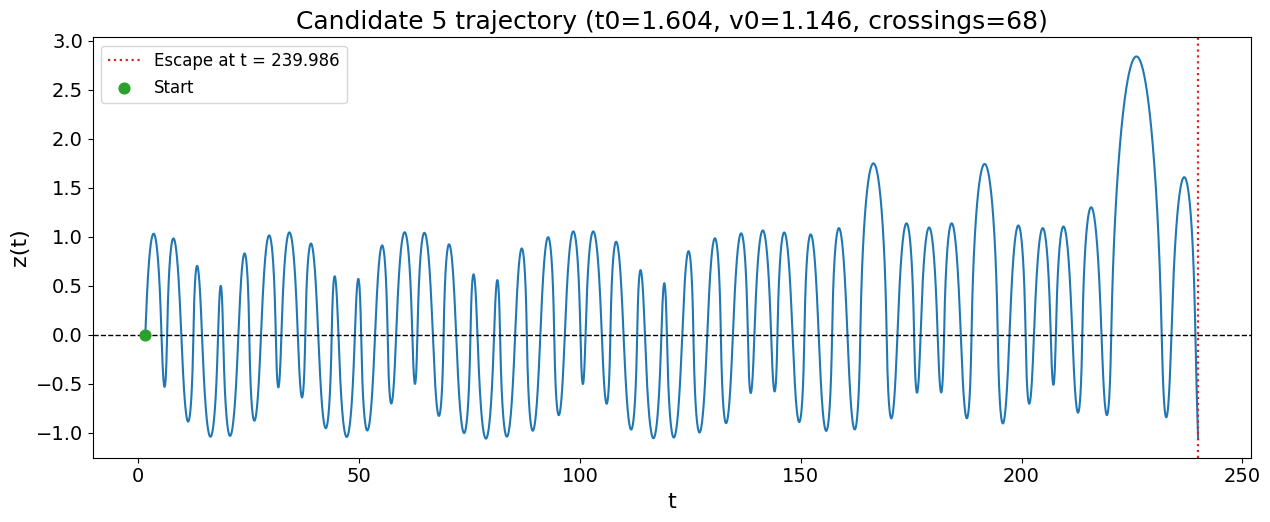

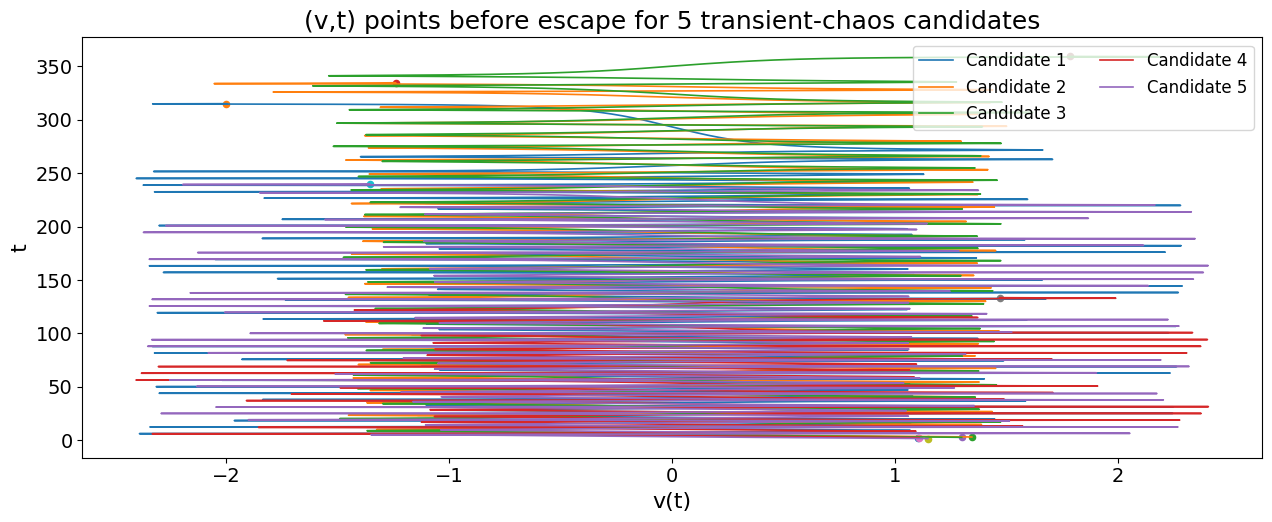

In [ ]:
from scipy.integrate import solve_ivp

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

trajectories = []
vt_points = []

for c in candidates:
    t0 = float(c["t"])
    v0 = float(c["v"])

    sol = solve_ivp(
        sim._rhs,
        (t0, t0 + 200.0 * sim.period),
        (0.0, v0),
        method=sim.solver_method,
        events=(sim._escape_event,),
        dense_output=True,
        rtol=sim.rtol,
        atol=sim.atol,
        max_step=sim.max_step,
)

    if len(sol.t_events[0]) == 0:
        raise RuntimeError(
            f"Escape event not detected for candidate {c['idx']} in integration window."
        )

    t_escape = float(sol.t_events[0][0])
    t_plot = np.linspace(t0, t_escape, 6000)
    z_plot, v_plot = sol.sol(t_plot)

    trajectories.append(
        {
            "candidate": c,
            "t_escape": t_escape,
            "t_plot": t_plot,
            "z_plot": z_plot,
            "v_plot": v_plot,
        }
    )

    vt_points.append((t_plot, v_plot, c["idx"]))

for tr in trajectories:
    c = tr["candidate"]
    t_escape = tr["t_escape"]
    t_plot = tr["t_plot"]
    z_plot = tr["z_plot"]

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(t_plot, z_plot, lw=1.5, color="tab:blue")
    ax.axhline(0.0, color="black", ls="--", lw=1.0)
    ax.axvline(t_escape, color="tab:red", ls=":", lw=1.6, label=f"Escape at t = {t_escape:.3f}")
    ax.scatter([float(c["t"])], [0.0], color="tab:green", s=60, zorder=3, label="Start")
    ax.set_xlabel("t")
    ax.set_ylabel("z(t)")
    ax.set_title(
        f"Candidate {c['idx']} trajectory (t0={c['t']:.3f}, v0={c['v']:.3f}, crossings={c['crossings']})"
    )
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

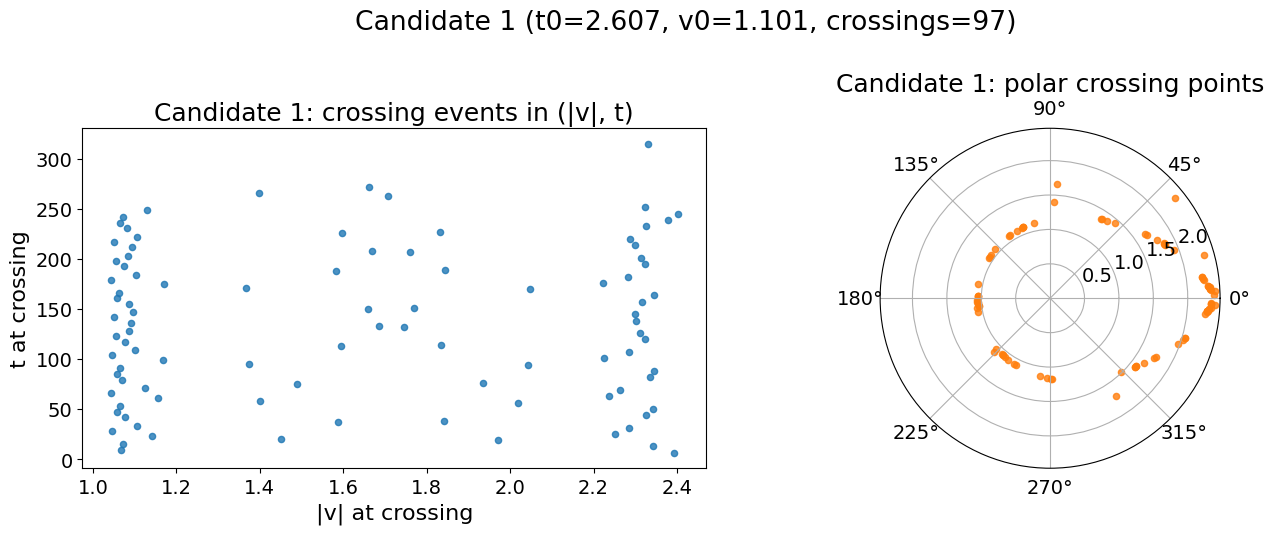

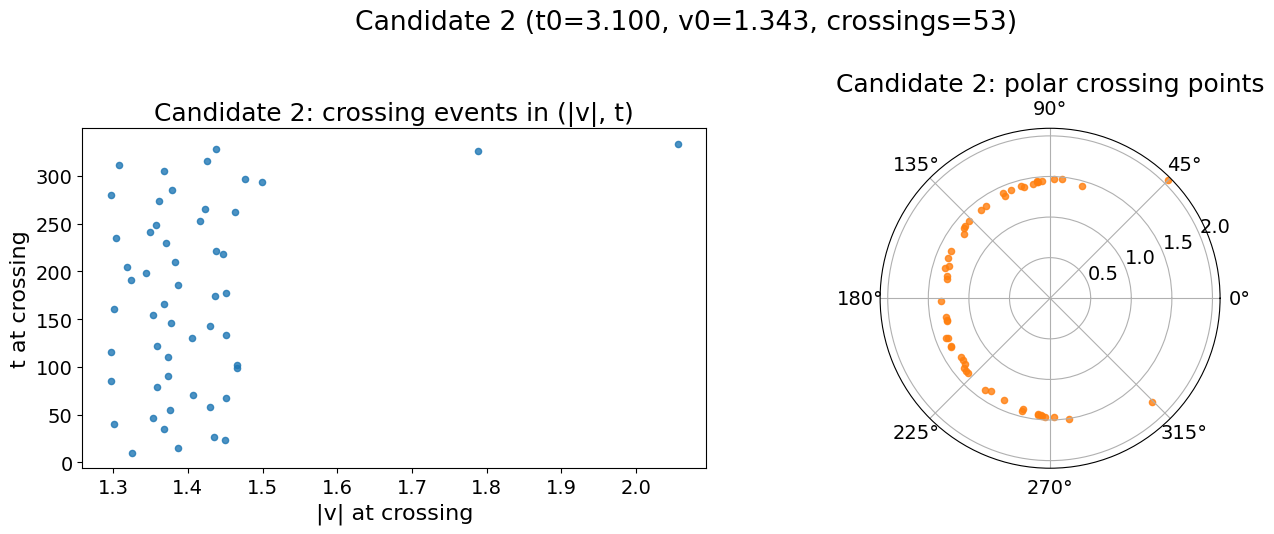

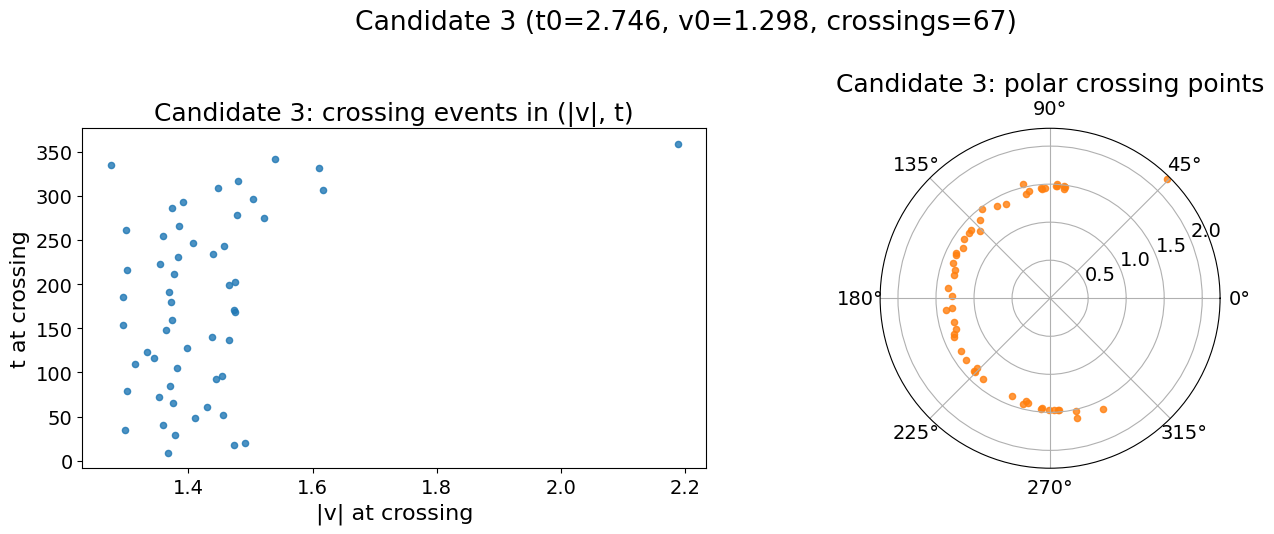

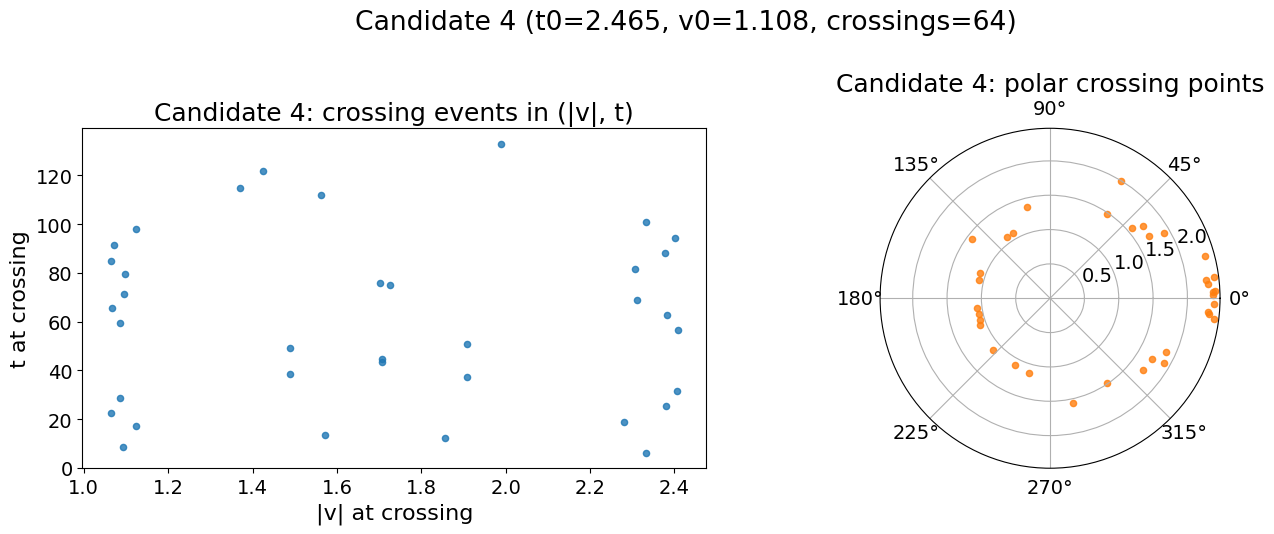

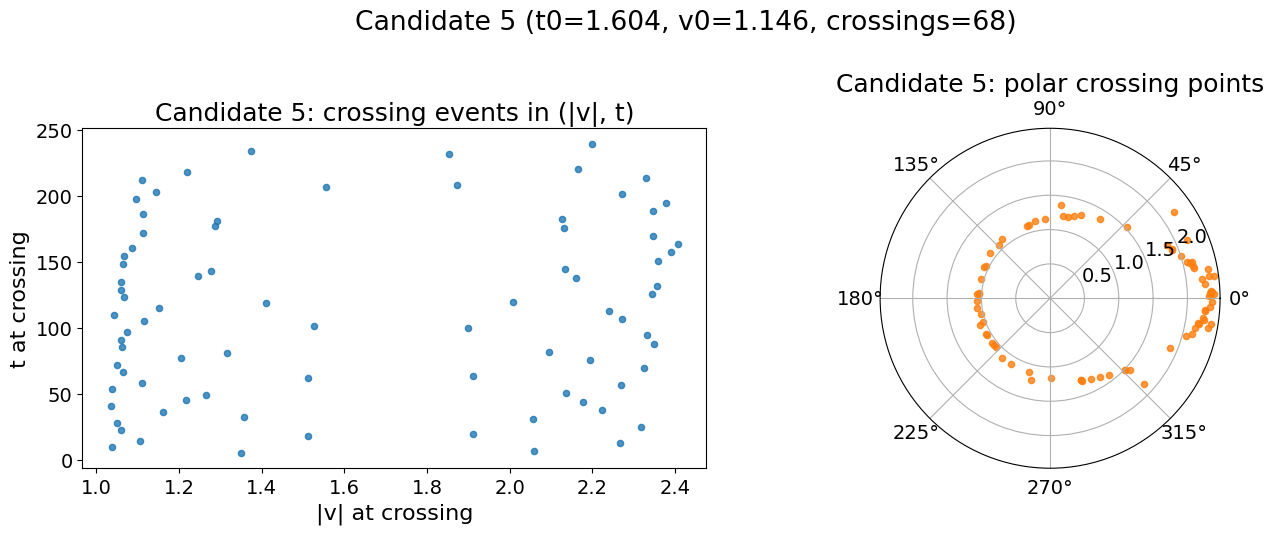

In [12]:
from scipy.integrate import solve_ivp

# Separate crossing-event plotting cell: per-candidate Cartesian and polar scatter
for c in candidates:
    t0 = float(c["t"])
    v0 = float(c["v"])

    def crossing_event(t, y):
        return y[0]
    crossing_event.terminal = False
    crossing_event.direction = 0.0

    sol = solve_ivp(
        sim._rhs,
        (t0, t0 + 200.0 * sim.period),
        (0.0, v0),
        method=sim.solver_method,
        events=(crossing_event, sim._escape_event),
        rtol=sim.rtol,
        atol=sim.atol,
        max_step=sim.max_step,
)

    if not sol.success:
        raise RuntimeError(
            f"Integration failed for candidate {c['idx']}: {sol.message}"
        )

    if len(sol.t_events[1]) == 0:
        raise RuntimeError(
            f"Escape event not detected for candidate {c['idx']} in integration window."
        )

    t_escape = float(sol.t_events[1][0])

    t_cross = np.array(sol.t_events[0], dtype=float)
    y_cross = np.array(sol.y_events[0], dtype=float)

    mask_after_start = t_cross > (t0 + 1e-10)
    t_cross = t_cross[mask_after_start]
    y_cross = y_cross[mask_after_start]

    if t_cross.size == 0:
        raise RuntimeError(f"No crossings detected for candidate {c['idx']} before escape.")

    t_cross = t_cross[t_cross <= t_escape]
    y_cross = y_cross[: t_cross.size]

    if t_cross.size == 0:
        raise RuntimeError(
            f"Crossings were detected only after escape for candidate {c['idx']}."
        )

    v_abs_cross = np.abs(y_cross[:, 1])
    theta_cross = np.mod(t_cross, 2.0 * np.pi)

    fig = plt.figure(figsize=(14, 5.5))
    ax_cart = fig.add_subplot(1, 2, 1)
    ax_polar = fig.add_subplot(1, 2, 2, projection="polar")

    ax_cart.scatter(v_abs_cross, t_cross, s=20, alpha=0.8, color="tab:blue")
    ax_cart.set_xlabel("|v| at crossing")
    ax_cart.set_ylabel("t at crossing")
    ax_cart.set_title(f"Candidate {c['idx']}: crossing events in (|v|, t)")

    ax_polar.scatter(theta_cross, v_abs_cross, s=20, alpha=0.8, color="tab:orange")
    ax_polar.set_title(f"Candidate {c['idx']}: polar crossing points")

    fig.suptitle(
        f"Candidate {c['idx']} (t0={c['t']:.3f}, v0={c['v']:.3f}, crossings={c['crossings']})"
    )
    fig.tight_layout()
    plt.show()

In [ ]:
from scipy.integrate import solve_ivp

candidate4 = next(c for c in candidates if c["idx"] == 4)
t0 = float(candidate4["t"])
v0 = float(candidate4["v"])

def crossing_event(t, y):
    return y[0]
crossing_event.terminal = False
crossing_event.direction = 0.0

sol4 = solve_ivp(
    sim._rhs,
    (t0, t0 + 200.0 * sim.period),
    (0.0, v0),
    method=sim.solver_method,
    events=(crossing_event, sim._escape_event),
    rtol=sim.rtol,
    atol=sim.atol,
    max_step=sim.max_step,
)

if len(sol4.t_events[1]) == 0:
    raise RuntimeError("Escape event not detected for candidate 4 in integration window.")

t_escape4 = float(sol4.t_events[1][0])
t_cross4 = np.array(sol4.t_events[0], dtype=float)
y_cross4 = np.array(sol4.y_events[0], dtype=float)

mask_before_escape = (t_cross4 > (t0 + 1e-10)) & (t_cross4 <= t_escape4)
t_cross4 = t_cross4[mask_before_escape]
y_cross4 = y_cross4[mask_before_escape]

n_crossings4 = t_cross4.size
n_down4 = int(np.sum(y_cross4[:, 1] < 0))
n_up4 = int(np.sum(y_cross4[:, 1] > 0))

print(f"Candidate 4 crossings before escape: {n_crossings4}")
print(f"Downward crossings (vz < 0): {n_down4}")
print(f"Upward crossings (vz > 0): {n_up4}")
n_crossings4